# Questions duplicates EDA

### **🎯 Problem Statement**

The goal of this project is to build a machine learning model for determining whether two text questions are duplicates.

The task is formulated as a binary classification problem, where:

- **1** — the questions are duplicates (have the same meaning);
- **0** — the questions are not duplicates.

The model should use the text of two questions to predict the probability that they are semantically equivalent.

### **📊 Evaluation Metric**

Cross-Entropy Loss (Log Loss) is used to evaluate the performance of the models.

This metric was chosen for the following reasons:

- it evaluates the quality of predicted probabilities rather than only the final classification decision;
- it is a standard metric for binary classification tasks;
- it strongly penalizes confident but incorrect predictions, which is especially important for this task.

Mathematically, Log Loss is defined as:

$$
\text{Log Loss} = -\frac{1}{N} \sum_{i=1}^{N}
\left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]
$$

where:

- **𝑦ᵢ** — the true class label;
- **𝑝ᵢ** — the predicted probability of class 1.

The lower the Log Loss value, the better the model performance.

### **🧾 Data Description**

The project uses a dataset consisting of pairs of text questions and a target variable.

Each record contains:

- **question1** — the first question;
- **question2** — the second question;
- **is_duplicate** — a binary target variable indicating whether the questions are duplicates.

The dataset contains natural language text, which requires preprocessing steps, including:

- tokenization;
- lemmatization;
- text vectorization.

In [1]:
import warnings  
warnings.filterwarnings("ignore")

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import seaborn as sns

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from src import Functions as fy

In [4]:
train_fname = '../data/quora_question_pairs_train.csv.zip'
df = pd.read_csv(train_fname)
df = df.dropna()
df_test = pd.read_csv('../data/quora_question_pairs_test.csv.zip')
df_test = df_test.dropna()

In [5]:
display(df.head(5)), df.info()

,id,qid1,qid2,question1,question2,is_duplicate
0,332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0
1,196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0
2,113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0
3,266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0
4,122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1


<class 'pandas.core.frame.DataFrame'>
Index: 323429 entries, 0 to 323431
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            323429 non-null  int64 
 1   qid1          323429 non-null  int64 
 2   qid2          323429 non-null  int64 
 3   question1     323429 non-null  object
 4   question2     323429 non-null  object
 5   is_duplicate  323429 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 17.3+ MB


(None, None)

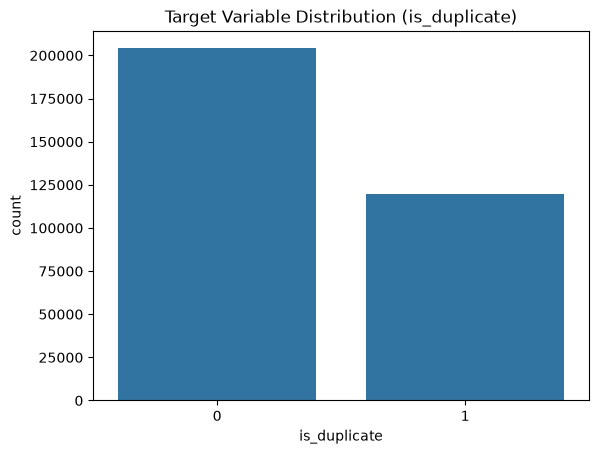

In [10]:
sns.countplot(x="is_duplicate", data=df)
plt.title("Target Variable Distribution (is_duplicate)")
plt.show()

In [12]:
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


There are almost no missing values, so we simply remove the few rows containing missing data.

In [6]:
df, vectorizer, tfidf_q1, tfidf_q2 = fy.tfidf_features(df)

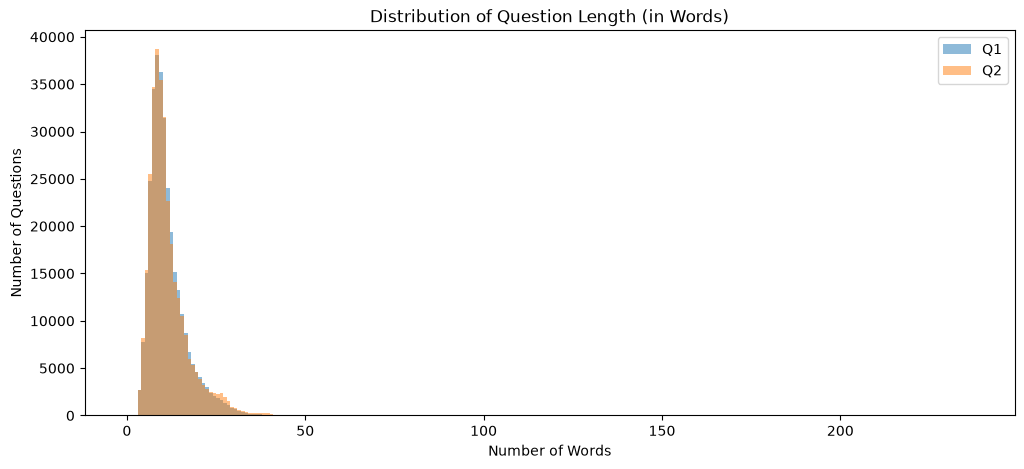

,len_q1_words,len_q2_words
count,323429.000000,323429.000000
mean,10.941715,11.184554
std,5.426282,6.312174
min,1.000000,1.000000
25%,7.000000,7.000000
50%,10.000000,10.000000
75%,13.000000,13.000000
max,125.000000,237.000000


In [ ]:
df['len_q1_words'] = df['question1'].apply(lambda x: len(str(x).split()))
df['len_q2_words'] = df['question2'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12,5))
bins = range(0, max(df['len_q1_words'].max(), df['len_q2_words'].max()) + 1)

plt.hist(df['len_q1_words'], bins=bins, alpha=0.5, label='Q1')
plt.hist(df['len_q2_words'], bins=bins, alpha=0.5, label='Q2')
plt.legend()
plt.title('Distribution of Question Length (in Words)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Questions')
plt.show()

df[['len_q1_words', 'len_q2_words']].describe()

Both questions have a similar length distribution in the dataset. Some outliers in question length are also present.

### **Most Frequent Words Analysis**



In [15]:
from collections import Counter
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop = set(stopwords.words('english'))

def clean_and_split(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop and len(w) > 1]
    return words

df['q1_words'] = df['question1'].apply(clean_and_split)
df['q2_words'] = df['question2'].apply(clean_and_split)

all_q1_words = [word for words in df['q1_words'] for word in words]
all_q2_words = [word for words in df['q2_words'] for word in words]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
top_q1 = pd.DataFrame(Counter(all_q1_words).most_common(20), columns=['word', 'count'])
top_q2 = pd.DataFrame(Counter(all_q2_words).most_common(20), columns=['word', 'count'])

from IPython.display import display, HTML

display(HTML(f"""
<div style="display: flex; gap: 50px;">
    <div>{top_q1.to_html()}</div>
    <div>{top_q2.to_html()}</div>
</div>
"""))

,word,count
0,best,27301
1,get,15205
2,india,11146
3,people,10138
4,like,10084
5,good,9593
6,would,9143
7,one,7519
8,quora,7077
9,make,7009


In [12]:
from wordcloud import WordCloud
text_all = " ".join(df["q1_clean"].astype(str)) + " " + " ".join(df["q2_clean"].astype(str))

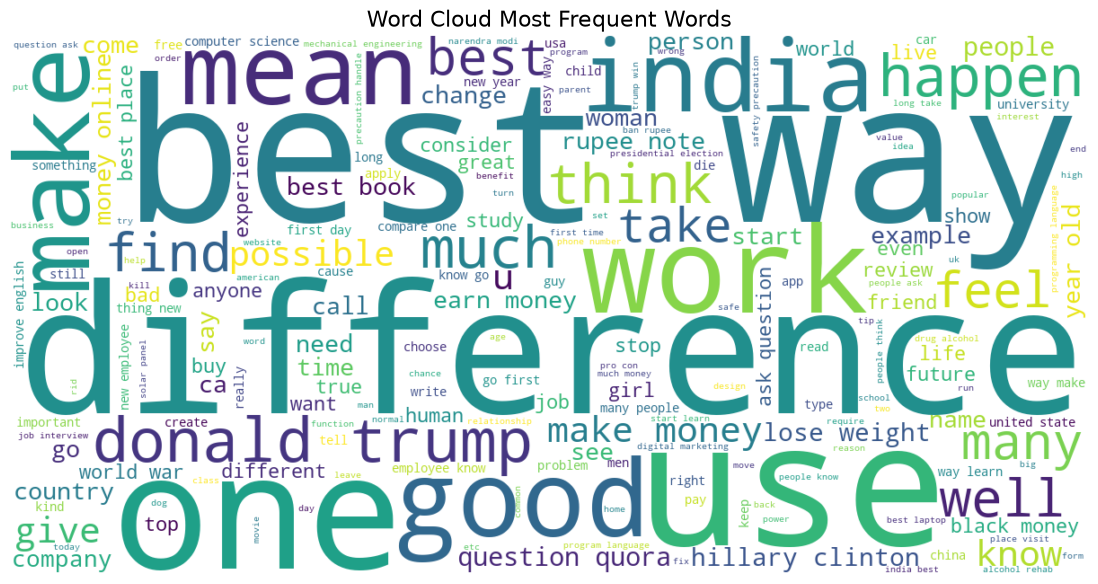

In [13]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    colormap="viridis"
).generate(text_all)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Most Frequent Words", fontsize=16)
plt.show()

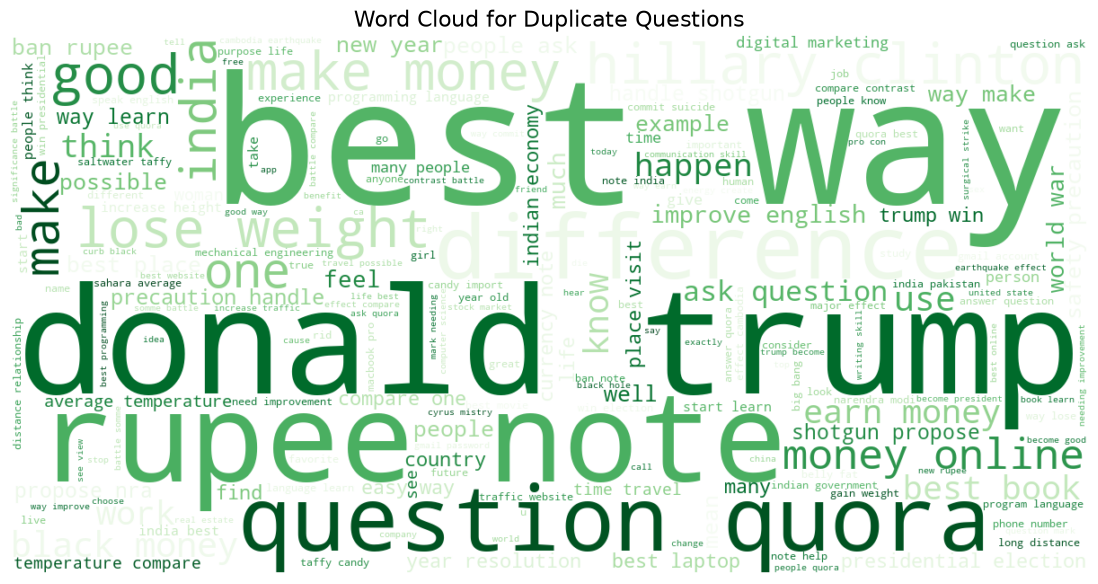

In [14]:
text_dup = " ".join(
    df[df["is_duplicate"] == 1]["q1_clean"].astype(str)
) + " " + " ".join(
    df[df["is_duplicate"] == 1]["q2_clean"].astype(str)
)

wc_dup = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    colormap="Greens"
).generate(text_dup)

plt.figure(figsize=(14, 7))
plt.imshow(wc_dup, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Duplicate Questions", fontsize=16)
plt.show()

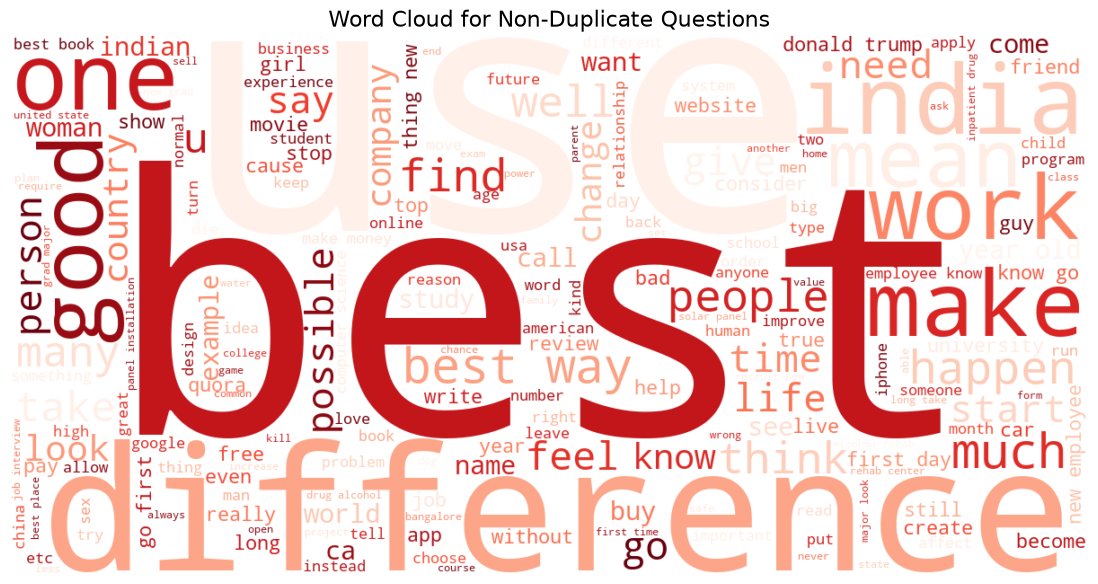

In [15]:
text_nondup = " ".join(
    df[df["is_duplicate"] == 0]["q1_clean"].astype(str)
) + " " + " ".join(
    df[df["is_duplicate"] == 0]["q2_clean"].astype(str)
)

wc_nondup = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    colormap="Reds"
).generate(text_nondup)

plt.figure(figsize=(14, 7))
plt.imshow(wc_nondup, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Non-Duplicate Questions", fontsize=16)
plt.show()

Word clouds were generated to visualize the most frequently used words in the dataset.

The comparison of duplicate and non-duplicate question pairs shows that although many common words appear in both classes, duplicate questions tend to contain more thematically and semantically related terms.

This analysis supports the use of semantic similarity features, such as TF-IDF and SBERT embeddings.

### **Analysis of Target Variable Dependencies on Text Features**

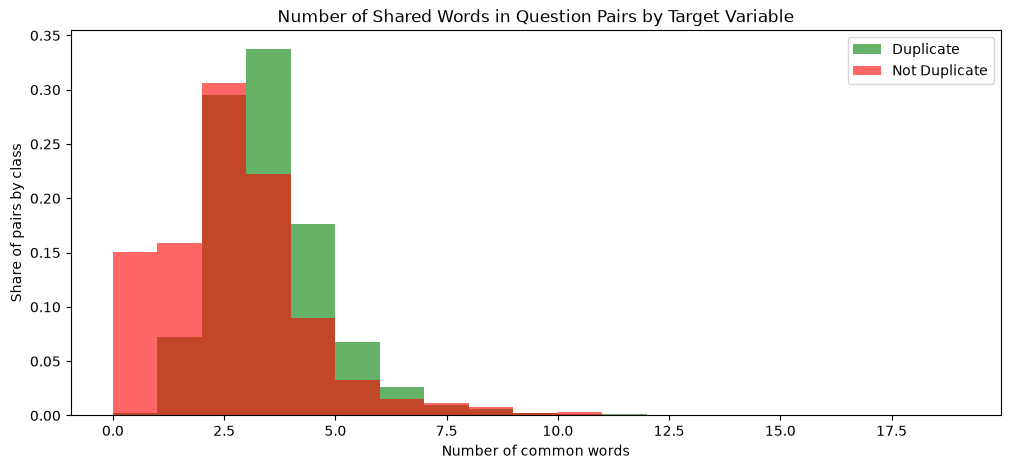

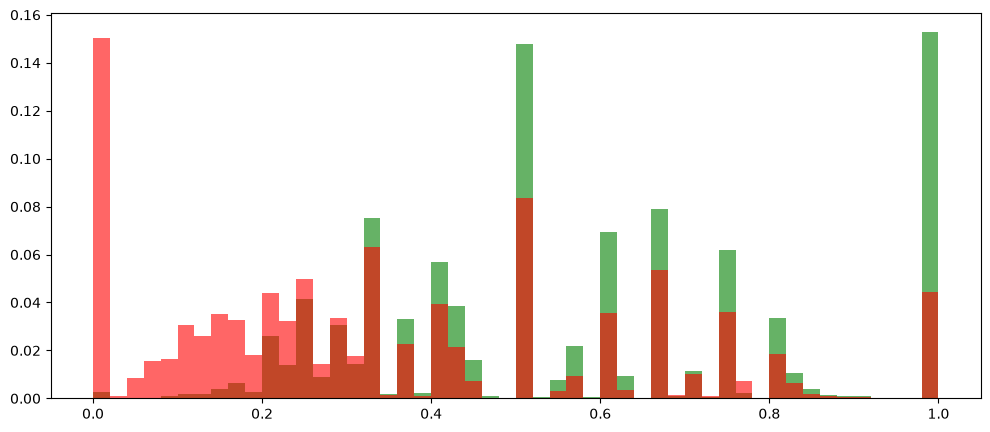

In [24]:
max_common = max(df['common_words'].max(), df['common_words'].max())
bins_common = np.arange(0, max_common + 2)

plt.figure(figsize=(12,5))

plt.hist(df[df['is_duplicate']==1]['common_words'], bins=bins_common, color='green', alpha=0.6,
         label='Duplicate', density=True)
plt.hist(df[df['is_duplicate']==0]['common_words'], bins=bins_common, color='red', alpha=0.6,
         label='Not Duplicate', density=True)

plt.title('Number of Shared Words in Question Pairs by Target Variable')
plt.xlabel('Number of common words')
plt.ylabel('Share of pairs by class')
plt.legend()
plt.show()

bins_jaccard = np.linspace(0, 1, 51)
weights_dup = np.ones(len(df[df['is_duplicate']==1])) / len(df[df['is_duplicate']==1])
weights_nodup = np.ones(len(df[df['is_duplicate']==0])) / len(df[df['is_duplicate']==0])

plt.figure(figsize=(12,5))
plt.hist(df[df['is_duplicate']==1]['jaccard'], bins=bins_jaccard, color='green', alpha=0.6,
         label='Duplicate', weights=weights_dup)
plt.hist(df[df['is_duplicate']==0]['jaccard'], bins=bins_jaccard, color='red', alpha=0.6,
         label='Not Duplicate', weights=weights_nodup)
plt.show()

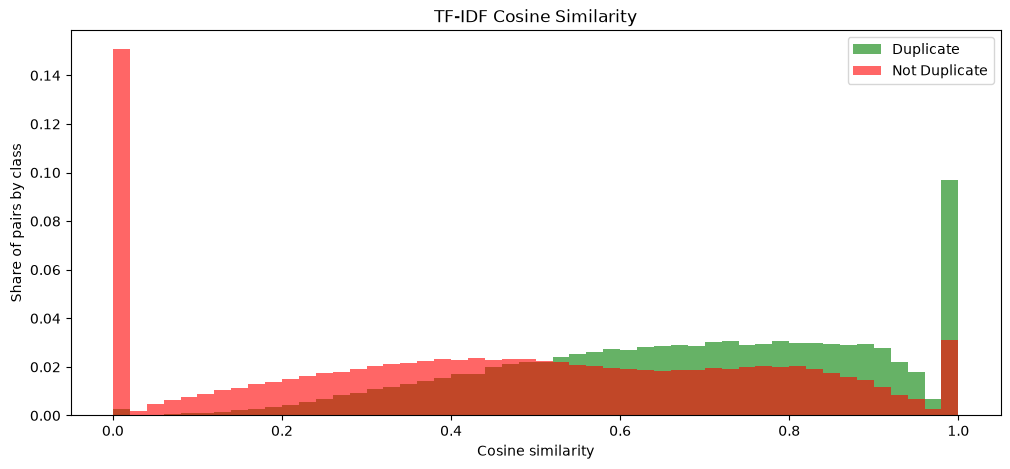

In [19]:
bins_cosine = np.linspace(0, 1, 51)

weights_dup = np.ones(len(df[df['is_duplicate']==1])) / len(df[df['is_duplicate']==1])
weights_nodup = np.ones(len(df[df['is_duplicate']==0])) / len(df[df['is_duplicate']==0])

plt.figure(figsize=(12,5))
plt.hist(df[df['is_duplicate']==1]['cosine_sim'], bins=bins_cosine, color='green', alpha=0.6,
         label='Duplicate', weights=weights_dup)
plt.hist(df[df['is_duplicate']==0]['cosine_sim'], bins=bins_cosine, color='red', alpha=0.6,
         label='Not Duplicate', weights=weights_nodup)

plt.title('TF-IDF Cosine Similarity')
plt.xlabel('Cosine similarity')

plt.ylabel('Share of pairs by class')
plt.legend()
plt.show()

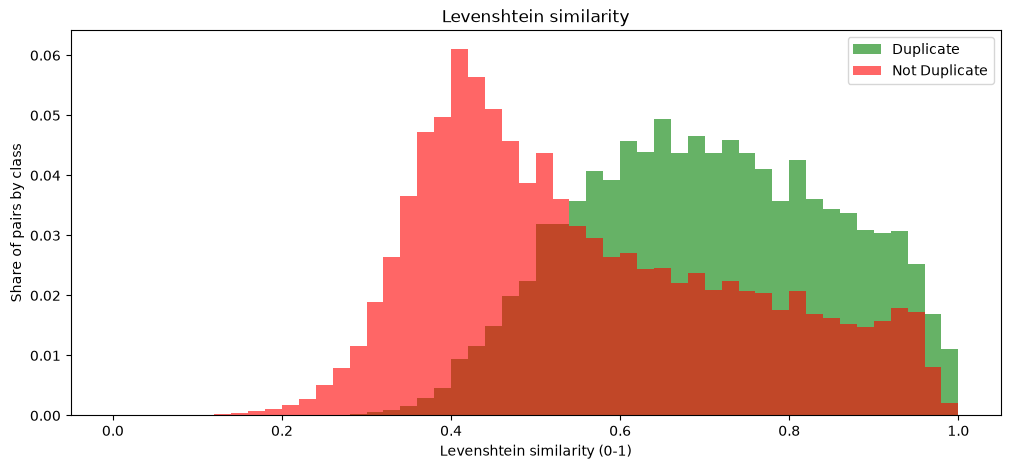

In [25]:
bins_lev = np.linspace(0, 1, 51)

weights_dup = np.ones(len(df[df['is_duplicate']==1])) / len(df[df['is_duplicate']==1])
weights_nodup = np.ones(len(df[df['is_duplicate']==0])) / len(df[df['is_duplicate']==0])

plt.figure(figsize=(12,5))
plt.hist(df[df['is_duplicate']==1]['lev_ratio'], bins=bins_lev, color='green', alpha=0.6,
         label='Duplicate', weights=weights_dup)
plt.hist(df[df['is_duplicate']==0]['lev_ratio'], bins=bins_lev, color='red', alpha=0.6,
         label='Not Duplicate', weights=weights_nodup)

plt.title('Levenshtein similarity')
plt.xlabel('Levenshtein similarity (0-1)')
plt.ylabel('Share of pairs by class')
plt.legend()
plt.show()

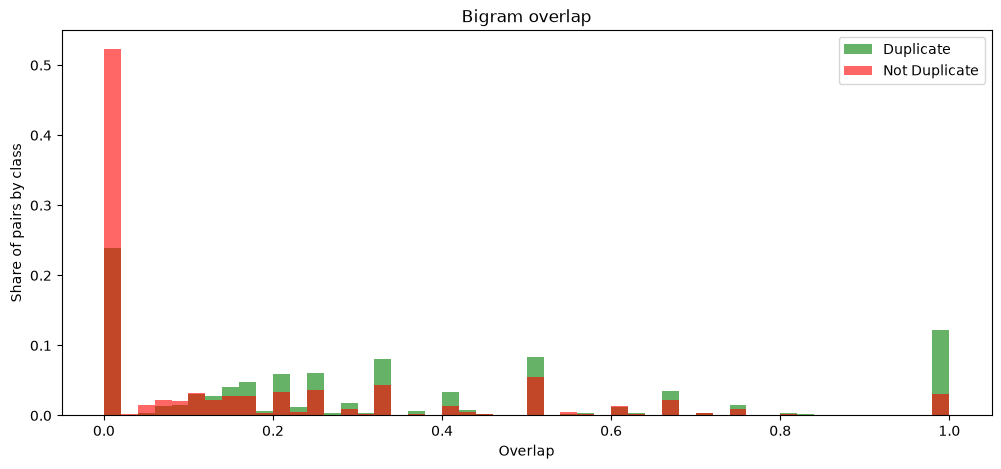

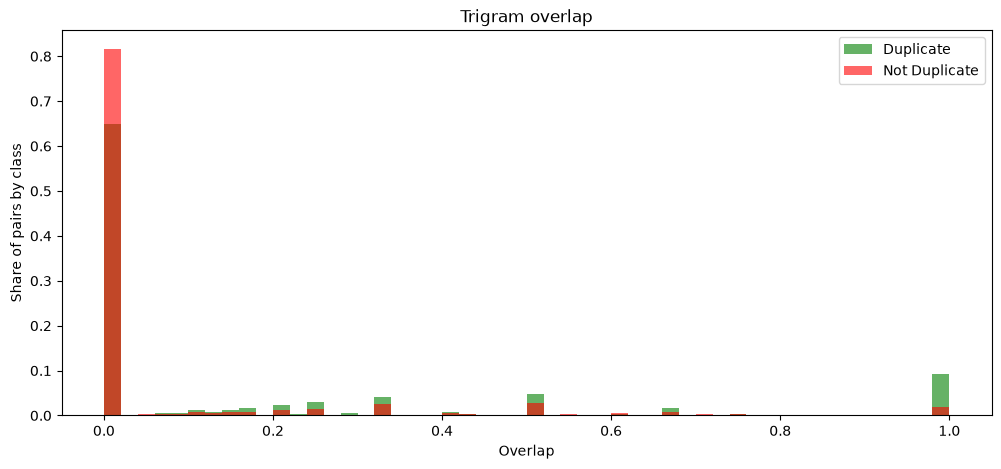

In [21]:
bins_ngram = np.linspace(0, 1, 51)

plt.figure(figsize=(12,5))
plt.hist(df[df['is_duplicate']==1]['bigram_overlap'], bins=bins_ngram, color='green', alpha=0.6,
         label='Duplicate', weights=weights_dup)
plt.hist(df[df['is_duplicate']==0]['bigram_overlap'], bins=bins_ngram, color='red', alpha=0.6,
         label='Not Duplicate', weights=weights_nodup)
plt.title('Bigram overlap')
plt.xlabel('Overlap')
plt.ylabel('Share of pairs by class')
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.hist(df[df['is_duplicate']==1]['trigram_overlap'], bins=bins_ngram, color='green', alpha=0.6,
         label='Duplicate', weights=weights_dup)
plt.hist(df[df['is_duplicate']==0]['trigram_overlap'], bins=bins_ngram, color='red', alpha=0.6,
         label='Not Duplicate', weights=weights_nodup)
plt.title('Trigram overlap')
plt.xlabel('Overlap')
plt.ylabel('Share of pairs by class')
plt.legend()
plt.show()

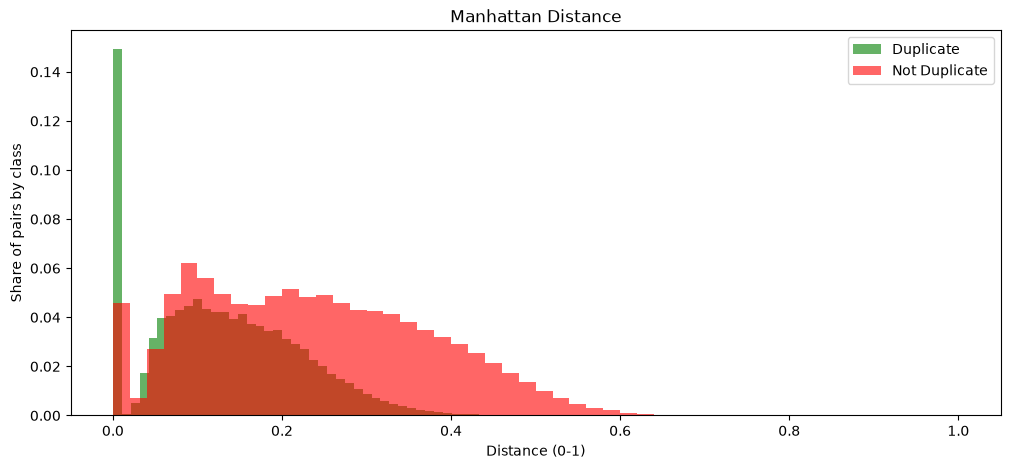

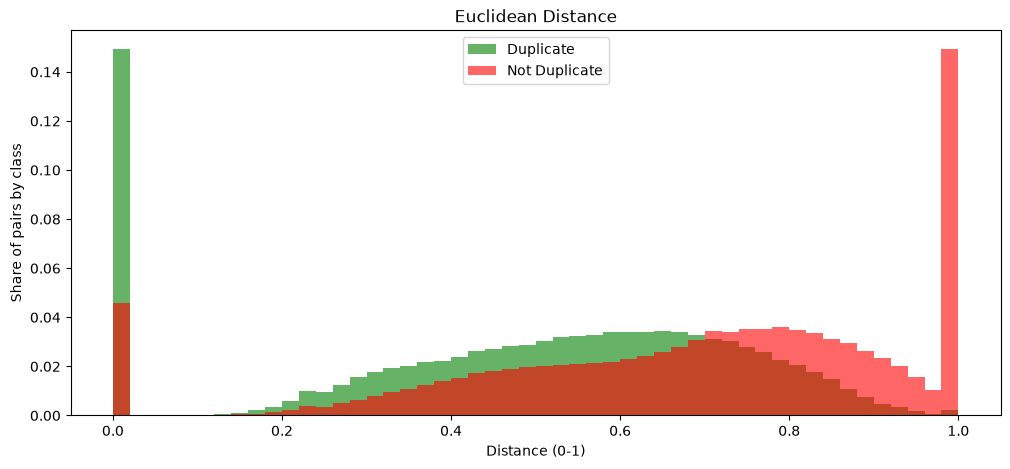

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['manhattan_norm', 'euclidean_norm']] = scaler.fit_transform(df[['manhattan', 'euclidean']])

weights_dup = np.ones(len(df[df['is_duplicate']==1])) / len(df[df['is_duplicate']==1])
weights_nodup = np.ones(len(df[df['is_duplicate']==0])) / len(df[df['is_duplicate']==0])

plt.figure(figsize=(12,5))
plt.hist(df[df['is_duplicate']==1]['manhattan_norm'], bins=50, color='green', alpha=0.6,
         label='Duplicate', weights=weights_dup)
plt.hist(df[df['is_duplicate']==0]['manhattan_norm'], bins=50, color='red', alpha=0.6,
         label='Not Duplicate', weights=weights_nodup)
plt.title('Manhattan Distance')
plt.xlabel('Distance (0-1)')
plt.ylabel('Share of pairs by class')
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.hist(df[df['is_duplicate']==1]['euclidean_norm'], bins=50, color='green', alpha=0.6,
         label='Duplicate', weights=weights_dup)
plt.hist(df[df['is_duplicate']==0]['euclidean_norm'], bins=50, color='red', alpha=0.6,
         label='Not Duplicate', weights=weights_nodup)
plt.title('Euclidean Distance')
plt.xlabel('Distance (0-1)')
plt.ylabel('Share of pairs by class')
plt.legend()
plt.show()

The constructed plots show that engineered features based on lexical and semantic similarity between questions demonstrate different patterns for duplicate and non-duplicate pairs.

The plots were normalized due to the different number of samples in each class.

Duplicate questions tend to have higher similarity scores (number of shared words, Jaccard coefficient, cosine similarity), while non-duplicate pairs generally have lower values. At the same time, distance-based metrics (Euclidean and Manhattan distances) show the opposite trend — lower values for semantically similar questions.

The obtained results indicate that the engineered features contain useful information for distinguishing duplicate and non-duplicate questions and can be effectively used in both classical machine learning models and ensemble approaches combined with text representations.

### 🧠 Conclusion

The exploratory data analysis demonstrated that duplicate question detection is a challenging NLP task where lexical similarity alone is not always sufficient. Questions with the same meaning may have different wording, while different questions can contain many overlapping words.

The analysis of text-based and engineered features showed that similarity measures such as shared word count, Jaccard similarity, and cosine similarity help distinguish duplicate question pairs. However, these features cannot fully capture the semantic meaning of the questions.

The results motivated the use of both traditional text representations (TF-IDF) and semantic embeddings (SBERT) to capture different aspects of question similarity. Combining handcrafted similarity features with semantic representations provides a more comprehensive approach for building a robust duplicate question classification model.